## TP de Machine Learning — Arbres de Décision
**Nom Complet :** Mohammed NASSIRI

**Utilisateur GitHub :** PunchArm255

---

Ce notebook implémente **3 algorithmes d'Arbres de Décision** :
1. **ID3** — Gain d'Information (Entropie)
2. **CART** — Impureté de Gini
3. **C4.5** — Ratio de Gain

Chaque algorithme est comparé entre une implémentation **From Scratch** et **Scikit-Learn**.

### IMPORTATION DES BIBLIOTHÈQUES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
%matplotlib inline

### IMPLÉMENTATIONS FROM SCRATCH

In [2]:
class ID3FromScratch:
    """Arbre de décision utilisant le Gain d'Information (Entropie)."""
    def __init__(self, max_depth=5):
        self.max_depth = max_depth; self.tree = None
    def _entropy(self, y):
        if len(y) == 0: return 0
        p = np.bincount(y, minlength=2) / len(y)
        return -np.sum([pi * np.log2(pi) for pi in p if pi > 0])
    def _info_gain(self, X, y, feat, thr):
        left = X[:, feat] <= thr; right = ~left
        if np.sum(left) == 0 or np.sum(right) == 0: return 0
        n = len(y)
        return self._entropy(y) - (np.sum(left)/n)*self._entropy(y[left]) - (np.sum(right)/n)*self._entropy(y[right])
    def _best_split(self, X, y):
        best_g, best_f, best_t = -1, None, None
        for f in range(X.shape[1]):
            for t in np.unique(X[:, f]):
                g = self._info_gain(X, y, f, t)
                if g > best_g: best_g, best_f, best_t = g, f, t
        return best_f, best_t
    def _build(self, X, y, depth=0):
        if len(np.unique(y)) == 1: return int(y[0])
        if depth >= self.max_depth or len(y) < 2: return int(np.round(np.mean(y)))
        f, t = self._best_split(X, y)
        if f is None: return int(np.round(np.mean(y)))
        left = X[:, f] <= t
        if np.sum(left) == 0 or np.sum(~left) == 0: return int(np.round(np.mean(y)))
        return {'f':f,'t':t,'l':self._build(X[left],y[left],depth+1),'r':self._build(X[~left],y[~left],depth+1)}
    def fit(self, X, y): self.tree = self._build(X, y)
    def _pred1(self, x, node):
        if not isinstance(node, dict): return node
        return self._pred1(x, node['l'] if x[node['f']] <= node['t'] else node['r'])
    def predict(self, X): return np.array([self._pred1(x, self.tree) for x in X])


class CARTFromScratch:
    """Arbre de décision utilisant l'Impureté de Gini."""
    def __init__(self, max_depth=5):
        self.max_depth = max_depth; self.tree = None
    def _gini(self, y):
        if len(y) == 0: return 0
        p = np.bincount(y, minlength=2) / len(y)
        return 1 - np.sum(p**2)
    def _best_split(self, X, y):
        best_g, best_f, best_t = float('inf'), None, None
        for f in range(X.shape[1]):
            for t in np.unique(X[:, f]):
                left = X[:, f] <= t; right = ~left
                if np.sum(left) == 0 or np.sum(right) == 0: continue
                n = len(y)
                g = (np.sum(left)/n)*self._gini(y[left]) + (np.sum(right)/n)*self._gini(y[right])
                if g < best_g: best_g, best_f, best_t = g, f, t
        return best_f, best_t
    def _build(self, X, y, depth=0):
        if len(np.unique(y)) == 1: return int(y[0])
        if depth >= self.max_depth or len(y) < 2: return int(np.round(np.mean(y)))
        f, t = self._best_split(X, y)
        if f is None: return int(np.round(np.mean(y)))
        left = X[:, f] <= t
        if np.sum(left) == 0 or np.sum(~left) == 0: return int(np.round(np.mean(y)))
        return {'f':f,'t':t,'l':self._build(X[left],y[left],depth+1),'r':self._build(X[~left],y[~left],depth+1)}
    def fit(self, X, y): self.tree = self._build(X, y)
    def _pred1(self, x, node):
        if not isinstance(node, dict): return node
        return self._pred1(x, node['l'] if x[node['f']] <= node['t'] else node['r'])
    def predict(self, X): return np.array([self._pred1(x, self.tree) for x in X])


class C45FromScratch:
    """Arbre de décision utilisant le Ratio de Gain (amélioration d'ID3)."""
    def __init__(self, max_depth=5):
        self.max_depth = max_depth; self.tree = None
    def _entropy(self, y):
        if len(y) == 0: return 0
        p = np.bincount(y, minlength=2) / len(y)
        return -np.sum([pi * np.log2(pi) for pi in p if pi > 0])
    def _gain_ratio(self, X, y, feat, thr):
        left = X[:, feat] <= thr; right = ~left
        if np.sum(left) == 0 or np.sum(right) == 0: return 0
        n = len(y); pl = np.sum(left)/n; pr = np.sum(right)/n
        ig = self._entropy(y) - pl*self._entropy(y[left]) - pr*self._entropy(y[right])
        si = -pl*np.log2(pl+1e-10) - pr*np.log2(pr+1e-10)
        return ig / si if si > 0 else 0
    def _best_split(self, X, y):
        best_g, best_f, best_t = -1, None, None
        for f in range(X.shape[1]):
            for t in np.unique(X[:, f]):
                g = self._gain_ratio(X, y, f, t)
                if g > best_g: best_g, best_f, best_t = g, f, t
        return best_f, best_t
    def _build(self, X, y, depth=0):
        if len(np.unique(y)) == 1: return int(y[0])
        if depth >= self.max_depth or len(y) < 2: return int(np.round(np.mean(y)))
        f, t = self._best_split(X, y)
        if f is None: return int(np.round(np.mean(y)))
        left = X[:, f] <= t
        if np.sum(left) == 0 or np.sum(~left) == 0: return int(np.round(np.mean(y)))
        return {'f':f,'t':t,'l':self._build(X[left],y[left],depth+1),'r':self._build(X[~left],y[~left],depth+1)}
    def fit(self, X, y): self.tree = self._build(X, y)
    def _pred1(self, x, node):
        if not isinstance(node, dict): return node
        return self._pred1(x, node['l'] if x[node['f']] <= node['t'] else node['r'])
    def predict(self, X): return np.array([self._pred1(x, self.tree) for x in X])

### PRÉPARATION DES DONNÉES
Les arbres de décision **ne nécessitent pas** de normalisation des données (contrairement à KNN/SVM).

In [3]:
df = pd.read_csv('data/medical_costs.csv')
median_cost = np.median(df['cost'].values)
y_class = (df['cost'].values >= median_cost).astype(int)
X_class = df[['age', 'bmi']].values

X_train, X_test, y_train, y_test = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42)

# Grille pour frontières de décision (pas de normalisation pour les arbres)
h = 0.5
x_min, x_max = X_class[:,0].min()-2, X_class[:,0].max()+2
y_min, y_max = X_class[:,1].min()-2, X_class[:,1].max()+2
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
grid = np.c_[xx.ravel(), yy.ravel()]
colors = np.where(y_class==1, '#e74c3c', '#3498db')
print(f"Échantillons : {len(df)} | Seuil médiane : {median_cost:.2f}")

Échantillons : 500 | Seuil médiane : 17141.39


### TEST 1 : ID3 (Gain d'Information)
L'algorithme **ID3** construit l'arbre en choisissant à chaque nœud l'attribut qui maximise le **gain d'information** basé sur l'**entropie** de Shannon.

Calcul des frontières de décision ID3...
Terminé !


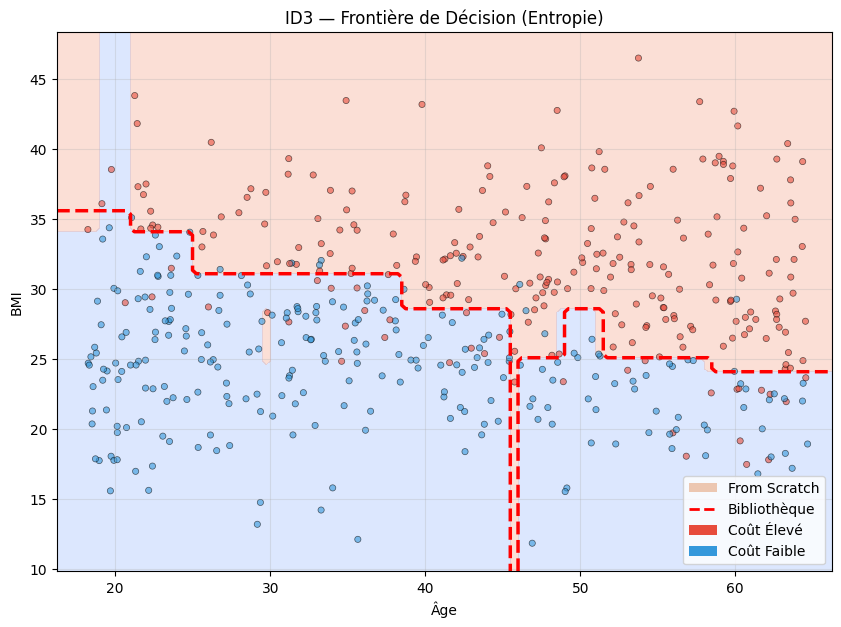

In [4]:
m_scratch = ID3FromScratch(max_depth=5); m_scratch.fit(X_train, y_train)
m_sklearn = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)
m_sklearn.fit(X_train, y_train)

print('Calcul des frontières de décision ID3...')
Z1 = m_scratch.predict(grid).reshape(xx.shape)
Z2 = m_sklearn.predict(grid).reshape(xx.shape)
print('Terminé !')

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z1, alpha=0.3, cmap='coolwarm', levels=np.linspace(-0.5,1.5,3))
plt.contour(xx, yy, Z2, colors='red', linestyles='dashed', linewidths=2.5, levels=[0.5])
plt.scatter(X_class[:,0], X_class[:,1], c=colors, edgecolors='black', s=20, alpha=0.6, linewidths=0.5)
plt.title('ID3 — Frontière de Décision (Entropie)')
plt.xlabel('Âge'); plt.ylabel('BMI')
plt.legend(handles=[
    Patch(facecolor='#d35400', alpha=0.3, label='From Scratch'),
    Line2D([0],[0], color='red', linestyle='dashed', linewidth=2, label='Bibliothèque'),
    Patch(facecolor='#e74c3c', label='Coût Élevé'),
    Patch(facecolor='#3498db', label='Coût Faible')])
plt.grid(True, alpha=0.3); plt.show()

### TEST 2 : CART (Impureté de Gini)
**CART** utilise l'**impureté de Gini** comme critère de division. Il produit toujours des **arbres binaires**.

Calcul des frontières de décision CART...
Terminé !


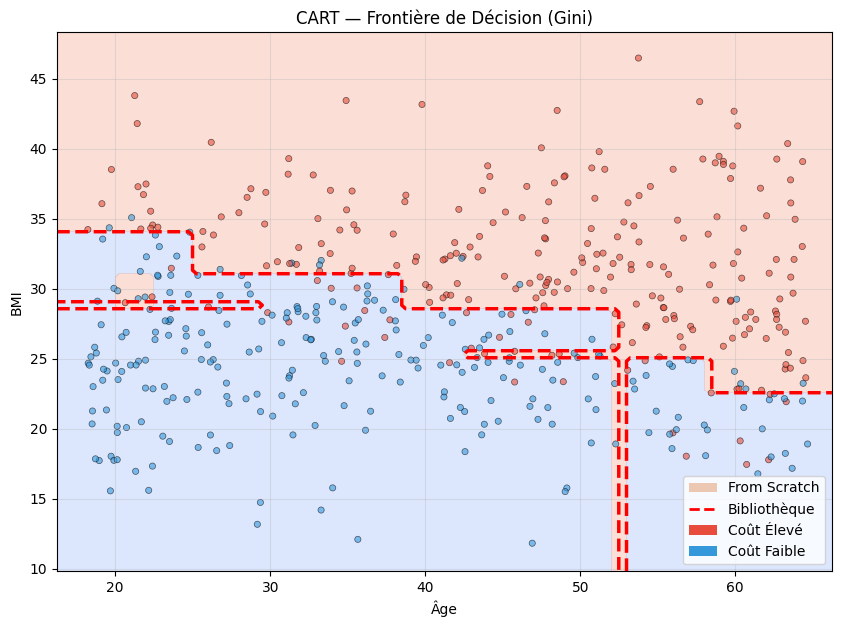

In [5]:
m_scratch = CARTFromScratch(max_depth=5); m_scratch.fit(X_train, y_train)
m_sklearn = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
m_sklearn.fit(X_train, y_train)

print('Calcul des frontières de décision CART...')
Z1 = m_scratch.predict(grid).reshape(xx.shape)
Z2 = m_sklearn.predict(grid).reshape(xx.shape)
print('Terminé !')

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z1, alpha=0.3, cmap='coolwarm', levels=np.linspace(-0.5,1.5,3))
plt.contour(xx, yy, Z2, colors='red', linestyles='dashed', linewidths=2.5, levels=[0.5])
plt.scatter(X_class[:,0], X_class[:,1], c=colors, edgecolors='black', s=20, alpha=0.6, linewidths=0.5)
plt.title('CART — Frontière de Décision (Gini)')
plt.xlabel('Âge'); plt.ylabel('BMI')
plt.legend(handles=[
    Patch(facecolor='#d35400', alpha=0.3, label='From Scratch'),
    Line2D([0],[0], color='red', linestyle='dashed', linewidth=2, label='Bibliothèque'),
    Patch(facecolor='#e74c3c', label='Coût Élevé'),
    Patch(facecolor='#3498db', label='Coût Faible')])
plt.grid(True, alpha=0.3); plt.show()

### TEST 3 : C4.5 (Ratio de Gain)
**C4.5** améliore ID3 en utilisant le **ratio de gain** au lieu du gain d'information brut. Cela normalise le gain par l'entropie de la division, évitant un biais vers les attributs à nombreuses valeurs.

Calcul des frontières de décision C4.5...
Terminé !


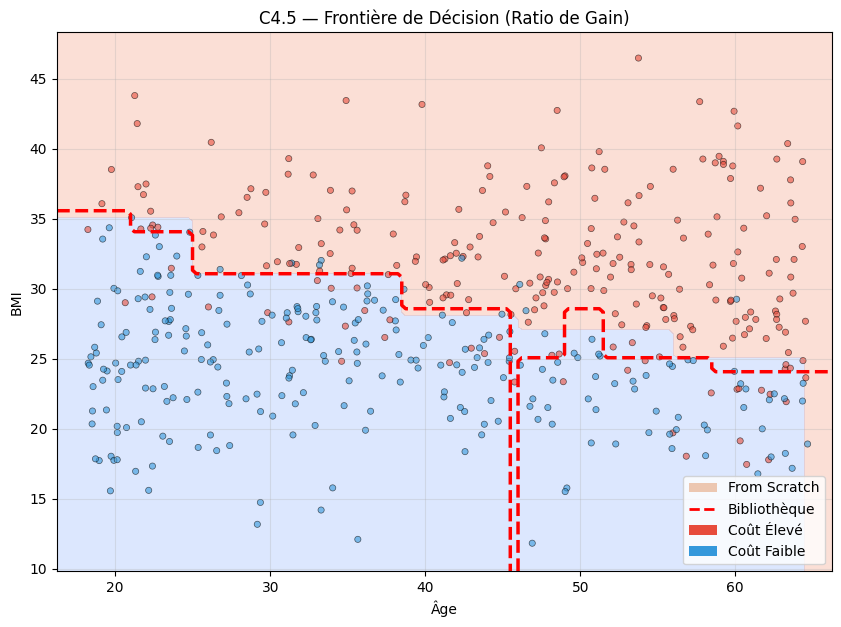

In [6]:
m_scratch = C45FromScratch(max_depth=5); m_scratch.fit(X_train, y_train)
m_sklearn = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)
m_sklearn.fit(X_train, y_train)

print('Calcul des frontières de décision C4.5...')
Z1 = m_scratch.predict(grid).reshape(xx.shape)
Z2 = m_sklearn.predict(grid).reshape(xx.shape)
print('Terminé !')

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z1, alpha=0.3, cmap='coolwarm', levels=np.linspace(-0.5,1.5,3))
plt.contour(xx, yy, Z2, colors='red', linestyles='dashed', linewidths=2.5, levels=[0.5])
plt.scatter(X_class[:,0], X_class[:,1], c=colors, edgecolors='black', s=20, alpha=0.6, linewidths=0.5)
plt.title('C4.5 — Frontière de Décision (Ratio de Gain)')
plt.xlabel('Âge'); plt.ylabel('BMI')
plt.legend(handles=[
    Patch(facecolor='#d35400', alpha=0.3, label='From Scratch'),
    Line2D([0],[0], color='red', linestyle='dashed', linewidth=2, label='Bibliothèque'),
    Patch(facecolor='#e74c3c', label='Coût Élevé'),
    Patch(facecolor='#3498db', label='Coût Faible')])
plt.grid(True, alpha=0.3); plt.show()